In [8]:
import numpy as np
from scipy.io import wavfile
from scipy.signal import correlate
from pathlib import Path


def read_wav_mono(path):
    sr, data = wavfile.read(path)
    data = data.astype(np.float64)

    # Convert stereo/multi-channel to mono
    if data.ndim > 1:
        data = data.mean(axis=1)

    # Scale int PCM to [-1, 1]
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data / max_val

    return sr, data


# Improved lag estimation: prefer best alignment quality, not just longest overlap.
# This fixes cases where plain cross-correlation can under-shift.

def best_overlap_times(path_a, path_b, min_overlap_seconds=1.0):
    sr_a, a = read_wav_mono(path_a)
    sr_b, b = read_wav_mono(path_b)

    if sr_a != sr_b:
        raise ValueError(f"Sample rates differ: {sr_a} vs {sr_b}")

    a_n = (a - np.mean(a)) / (np.std(a) + 1e-12)
    b_n = (b - np.mean(b)) / (np.std(b) + 1e-12)

    # Numerator of NCC for each lag
    cc = correlate(a_n, b_n, mode="full", method="fft")
    lags = np.arange(-len(b_n) + 1, len(a_n))

    # Overlap length for each lag
    start_a = np.maximum(0, lags)
    start_b = np.maximum(0, -lags)
    overlap_len = np.minimum(len(a_n) - start_a, len(b_n) - start_b)

    # Score by mean correlation over overlap to avoid bias toward larger overlap only
    safe_len = np.maximum(overlap_len, 1)
    mean_corr = cc / safe_len

    min_overlap_samples = int(min_overlap_seconds * sr_a)
    valid = overlap_len >= min_overlap_samples
    if not np.any(valid):
        valid = overlap_len > 0

    best_idx = np.argmax(np.where(valid, mean_corr, -np.inf))
    best_lag = int(lags[best_idx])

    s_a = max(0, best_lag)
    s_b = max(0, -best_lag)
    ol = min(len(a_n) - s_a, len(b_n) - s_b)

    if ol <= 0:
        return {
            "lag_samples": int(best_lag),
            "sr": sr_a,
            "overlap_seconds": 0.0,
            "a_range": None,
            "b_range": None,
        }

    e_a = s_a + ol
    e_b = s_b + ol

    return {
        "lag_samples": int(best_lag),
        "sr": sr_a,
        "overlap_seconds": ol / sr_a,
        "a_range": (s_a / sr_a, e_a / sr_a),
        "b_range": (s_b / sr_a, e_b / sr_a),
    }





pairs = [
    ("dataset/aggressive/6761.wav", "dataset/aggressive/6762.wav"),
    ("dataset/aggressive/6776.wav", "dataset/aggressive/6777.wav"),
    ("dataset/aggressive/6812.wav", "dataset/aggressive/6813.wav"),
    ("dataset/romantic/5204.wav", "dataset/romantic/5205.wav"),
    ("dataset/dramatic/9124.wav", "dataset/dramatic/9125.wav"),
    ("dataset/happy/17884.wav", "dataset/happy/17885.wav"),
    ("dataset/sad/5547.wav", "dataset/sad/5548.wav"),
]


print("Updated overlap windows (alignment-focused scoring):")
for a, b in pairs:
    res = best_overlap_times(Path(a), Path(b), min_overlap_seconds=1.0)
    print(f"\n{a}  <->  {b}")
    if res["a_range"] is None:
        print("  No overlap detected")
        continue

    a0, a1 = res["a_range"]
    b0, b1 = res["b_range"]
    print(f"  Overlap duration: {res['overlap_seconds']:.3f} s")
    print(f"  In first file : {a0:.3f} s -> {a1:.3f} s")
    print(f"  In second file: {b0:.3f} s -> {b1:.3f} s")
    print(f"  Best lag: {res['lag_samples']} samples @ {res['sr']} Hz")


Updated overlap windows (alignment-focused scoring):

dataset/aggressive/6761.wav  <->  dataset/aggressive/6762.wav
  Overlap duration: 4.000 s
  In first file : 1.000 s -> 5.000 s
  In second file: 0.000 s -> 4.000 s
  Best lag: 44100 samples @ 44100 Hz

dataset/aggressive/6776.wav  <->  dataset/aggressive/6777.wav
  Overlap duration: 4.000 s
  In first file : 1.000 s -> 5.000 s
  In second file: 0.000 s -> 4.000 s
  Best lag: 44100 samples @ 44100 Hz

dataset/aggressive/6812.wav  <->  dataset/aggressive/6813.wav
  Overlap duration: 4.000 s
  In first file : 1.000 s -> 5.000 s
  In second file: 0.000 s -> 4.000 s
  Best lag: 44100 samples @ 44100 Hz

dataset/romantic/5204.wav  <->  dataset/romantic/5205.wav
  Overlap duration: 4.000 s
  In first file : 1.000 s -> 5.000 s
  In second file: 0.000 s -> 4.000 s
  Best lag: 44100 samples @ 44100 Hz

dataset/dramatic/9124.wav  <->  dataset/dramatic/9125.wav
  Overlap duration: 4.000 s
  In first file : 1.000 s -> 5.000 s
  In second file: 0

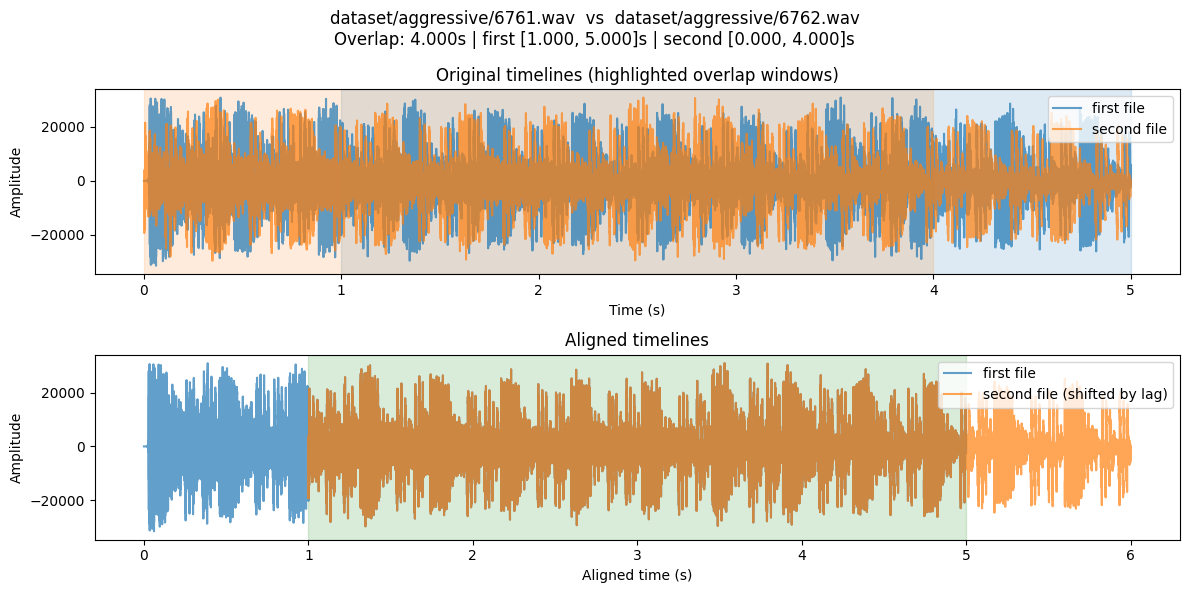

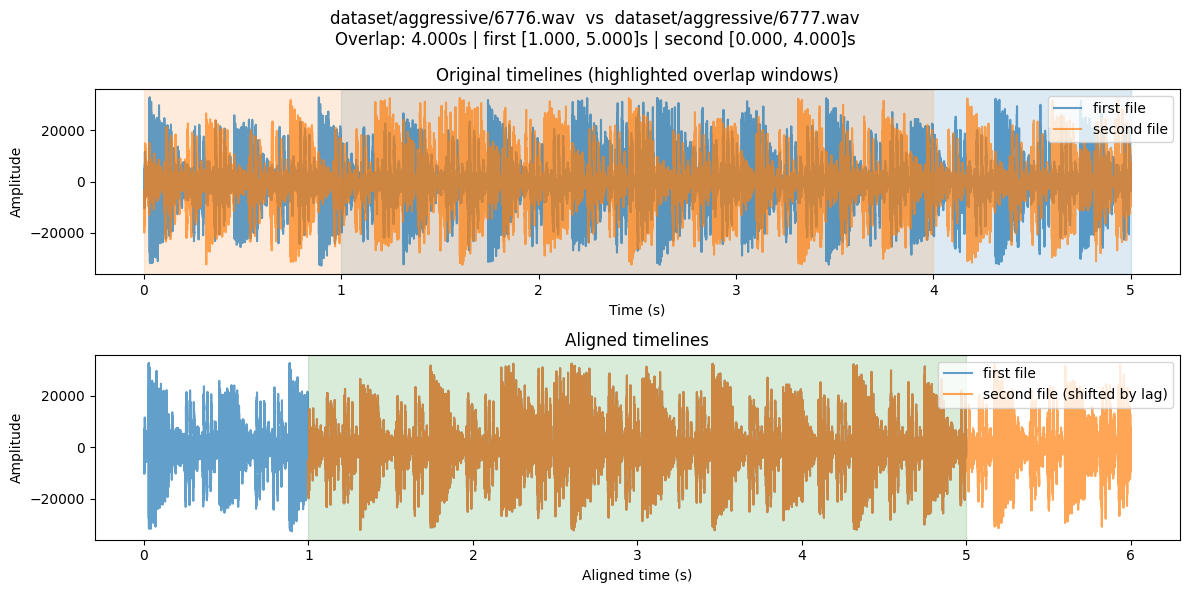

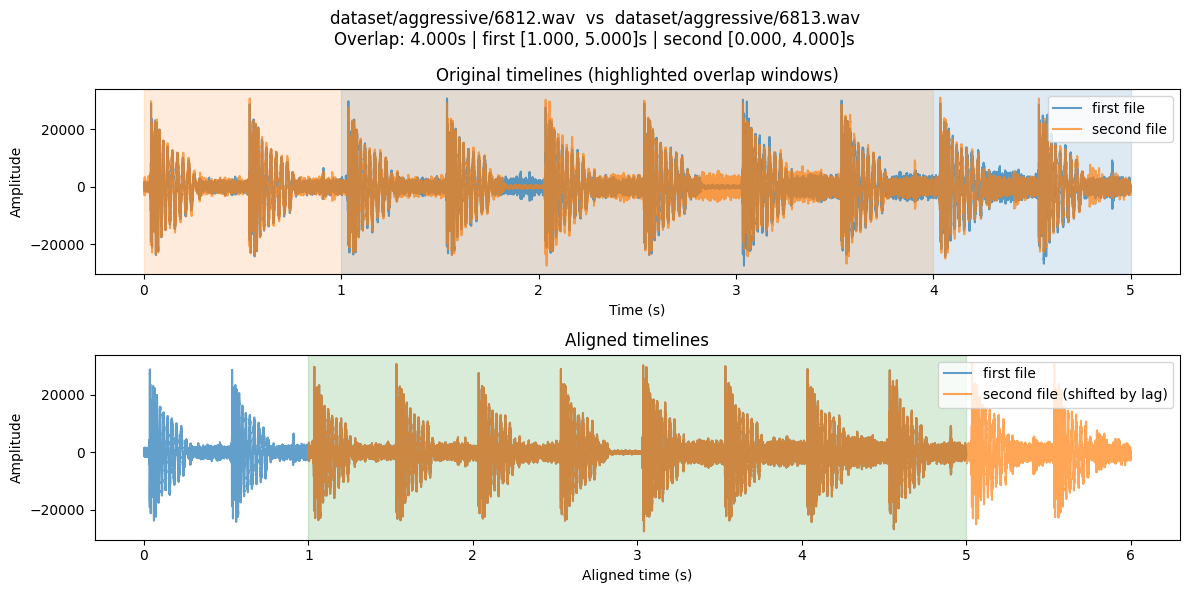

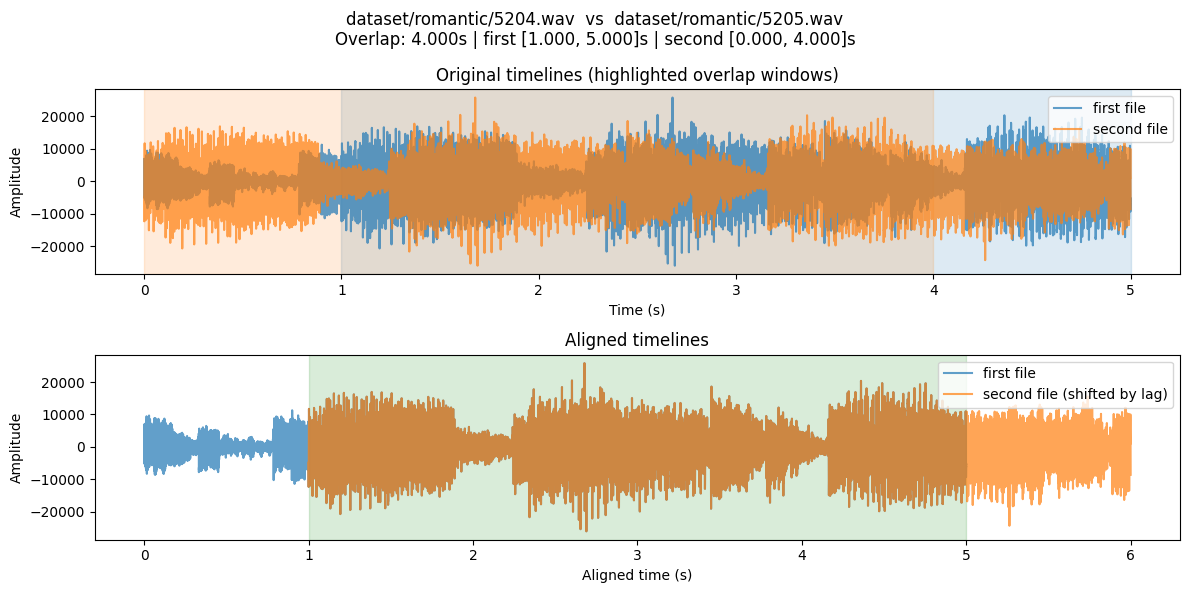

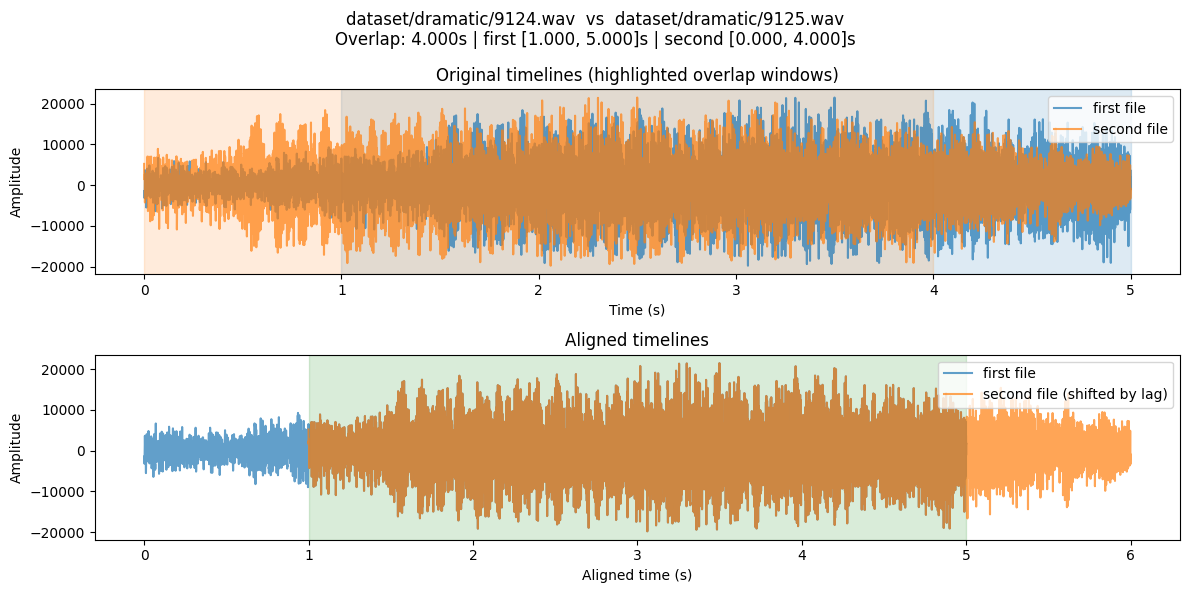

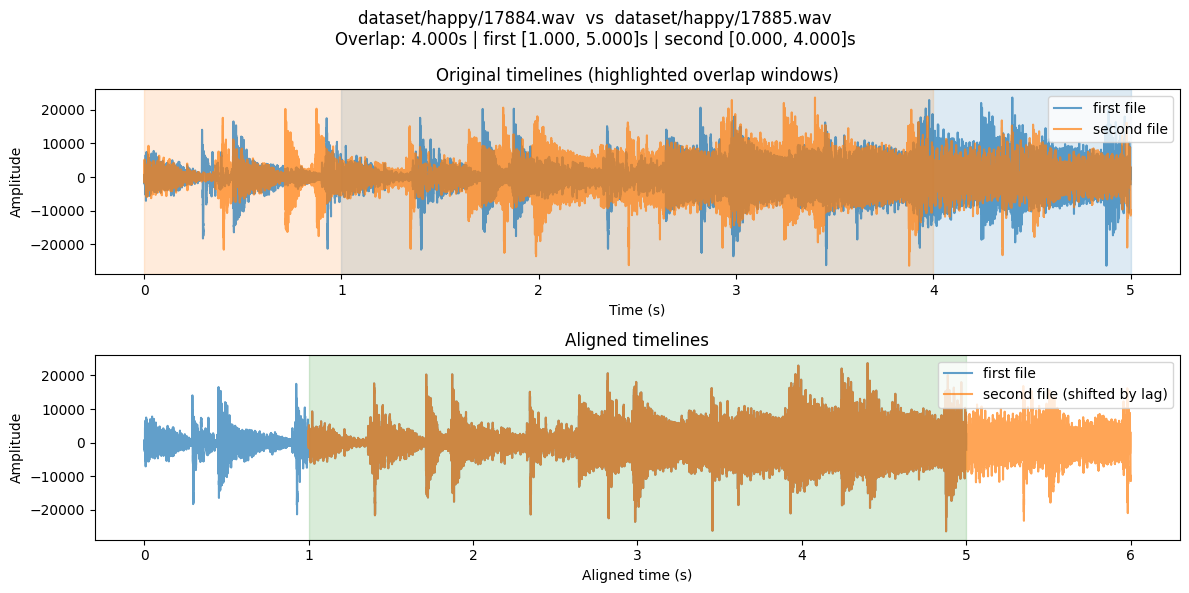

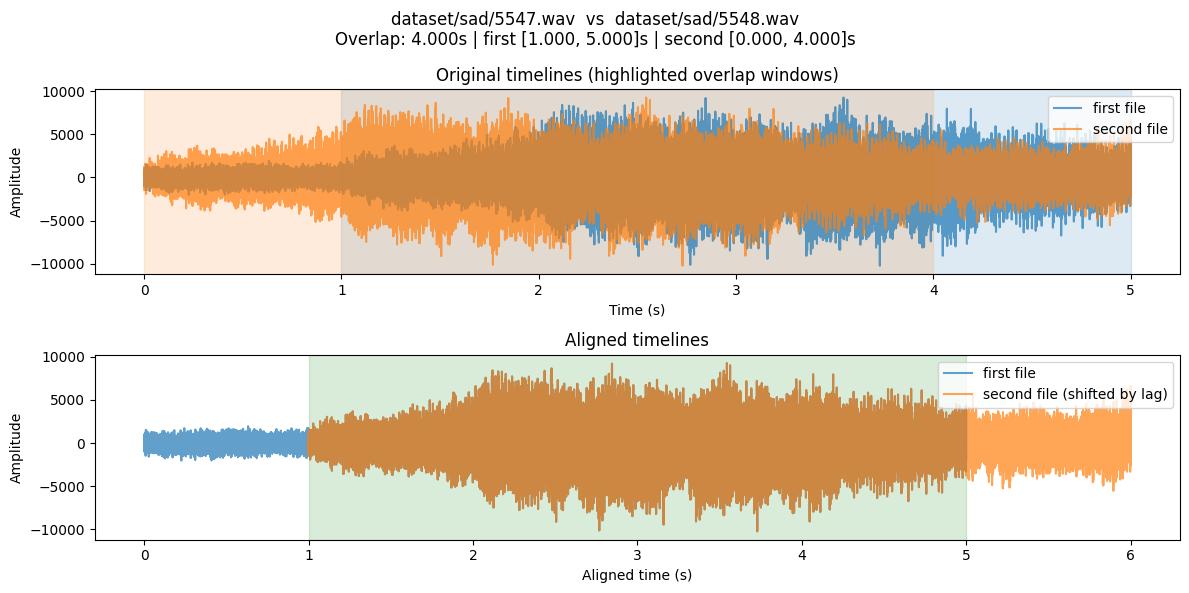

In [9]:
import matplotlib.pyplot as plt


def plot_overlap_pair(path_a, path_b):
    res = best_overlap_times(Path(path_a), Path(path_b))

    sr_a, a = read_wav_mono(path_a)
    sr_b, b = read_wav_mono(path_b)
    if sr_a != sr_b:
        raise ValueError(f"Sample rates differ: {sr_a} vs {sr_b}")

    if res["a_range"] is None:
        print(f"No overlap detected for {path_a} and {path_b}")
        return

    # Convert overlap time ranges back to sample indices
    a0 = int(round(res["a_range"][0] * sr_a))
    a1 = int(round(res["a_range"][1] * sr_a))
    b0 = int(round(res["b_range"][0] * sr_b))
    b1 = int(round(res["b_range"][1] * sr_b))

    t_a = np.arange(len(a)) / sr_a
    t_b = np.arange(len(b)) / sr_b

    # Build aligned timeline using lag
    lag_sec = res["lag_samples"] / sr_a
    t_b_aligned = t_b + lag_sec

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

    # Top: raw signals with overlap highlighted in their own timelines
    axes[0].plot(t_a, a, alpha=0.7, label="first file")
    axes[0].plot(t_b, b, alpha=0.7, label="second file")
    axes[0].axvspan(a0 / sr_a, a1 / sr_a, color="C0", alpha=0.15)
    axes[0].axvspan(b0 / sr_b, b1 / sr_b, color="C1", alpha=0.15)
    axes[0].set_title("Original timelines (highlighted overlap windows)")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend(loc="upper right")

    # Bottom: aligned view where overlap should coincide
    axes[1].plot(t_a, a, alpha=0.7, label="first file")
    axes[1].plot(t_b_aligned, b, alpha=0.7, label="second file (shifted by lag)")
    axes[1].axvspan(a0 / sr_a, a1 / sr_a, color="green", alpha=0.15)
    axes[1].set_title("Aligned timelines")
    axes[1].set_xlabel("Aligned time (s)")
    axes[1].set_ylabel("Amplitude")
    axes[1].legend(loc="upper right")

    fig.suptitle(
        f"{path_a}  vs  {path_b}\n"
        f"Overlap: {res['overlap_seconds']:.3f}s | "
        f"first [{res['a_range'][0]:.3f}, {res['a_range'][1]:.3f}]s | "
        f"second [{res['b_range'][0]:.3f}, {res['b_range'][1]:.3f}]s"
    )
    fig.tight_layout()
    plt.show()


for a, b in pairs:
    plot_overlap_pair(a, b)